# Module 3: Programming Assignment

In [1]:
library(testthat)
library(ggplot2)

## Problem 1: Rate of wildfires

Imagine that, over the past $50$ years Colorado has experienced an average of $\lambda_0 = 150$ large wildfires per year. For the next $10$ years you will record the number of large fires in Colorado and then fit a Poisson/gamma model to these data. Let the rate of large fires in this future period, $\lambda$, have prior $\lambda ∼ \Gamma(a,b)$. 

**Select $a$ and $b$ so that the prior is "uninformative" with prior variance around $100$ and gives equal probability on the hypotheses**

$$H_0: \lambda \le 150, \,\,\,\,\,\,\,\, H_1: \lambda > 150.$$


Note that, for $\lambda \sim \Gamma(a,b)$, $Var(\lambda) = \frac{a}{b^2}$, but that the median of $\lambda$ does not have a nice closed form formula; so, you will need to do a grid search to find $a$ and/or $b$. 

**1 (a) [2 points] Establish a dense grid of possible values for $b$ using the function `seq()`.  Your grid of possible values should contain `m=1000` evenly spaced values between 0.1 and 2.  Store your grid of possible $b$ values in a variable named `b_grid`.** 

In [3]:
m = 1000
b_grid = seq(0.1, 2, length.out=m)
#b_grid
# your code here
#.NotYetImplemented()

**1 (b) [2 points] Using `b_grid`, establish a vector of associated $a$ values and call it `a_grid`.  Note that we want the variance of the prior distribution on $\lambda$ to be about 100 (use 100), and we know that for $\lambda \sim \Gamma(a,b)$, $Var(\lambda) = \frac{a}{b^2}$.** 

In [4]:
a_grid = 100*b_grid^2
# your code here
#.NotYetImplemented()
#a_grid / b_grid^2

**1 (c) [3 points] For each pair of components in `a_grid` and `b_grid`, calculate the median value using `qgamma()`.  Use `a_grid` and `b_grid` as the shape and rate parameters (i.e. what we are calling $a$ and $b$).  Store these median values in a vector named `median_values`.**  

In [5]:
median_values = rep(0, m)

for (i in 1:length(a_grid)) {
     median_values[i] <- qgamma(0.5, a_grid[i], b_grid[i])
}

#median_values
# your code here
#.NotYetImplemented()

**1 (d) [3 points] Plot`median_values` vs. `b_grid` to visually estimate the value for $b$ that ensures $\lambda = 150$.  Calculate the exact value of `b_grid` minimizes the absolute distance between the median value established using `qgamma` and 150.  Store this value in a variable named `b`.  Using `b` calculate $a$ and store it in a variable named `a`.**  

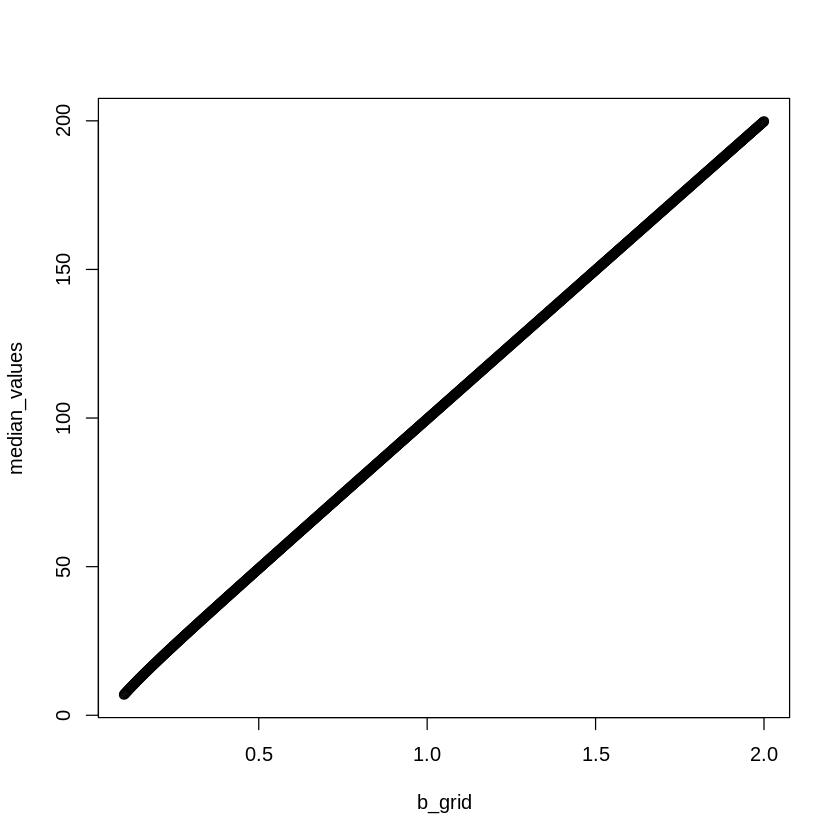

In [6]:
plot(b_grid, median_values)
index <- which.min(abs(median_values - 150))
b = b_grid[index]
a = 100*b^2
# your code here
#.NotYetImplemented()

**1 (e) [4 points] Ten years have gone by and the vector `fire` below represents the number of large fires in Colorado each year for these ten years. Calculate the posterior distribution using these data and the prior $\lambda ∼ \Gamma(a,b)$ with the `a` and `b` computed above in 1 (d) for 200 evenly spaced $\lambda$ values between 140 and 185 (i.e., use `seq(140,185,length.out=200)`). Store your grid of lambda values in a vector labeled `l_grid` and the values for the posterior in a vector labeled, `post`.**

HINT: There is a conjugate relationship here to take advantage of!

In [7]:
fire = c(145, 142, 158, 143, 185, 164, 141, 148, 151, 150)

In [12]:
l_grid = seq(140, 185, length.out=200)
#l_grid
#var(fire)
#a/b^2
post = dgamma(l_grid, a + sum(fire), b + length(fire))
#mean(rgamma(10000, a + sum(fire), b + length(fire)))
#(a + sum(fire)) / (b + length(fire))
# your code here
#.NotYetImplemented()

**1 (f) [2 points] Plot the posterior distribution computed in 1 (e) using ggplot. Save the plot to the variable `p`**

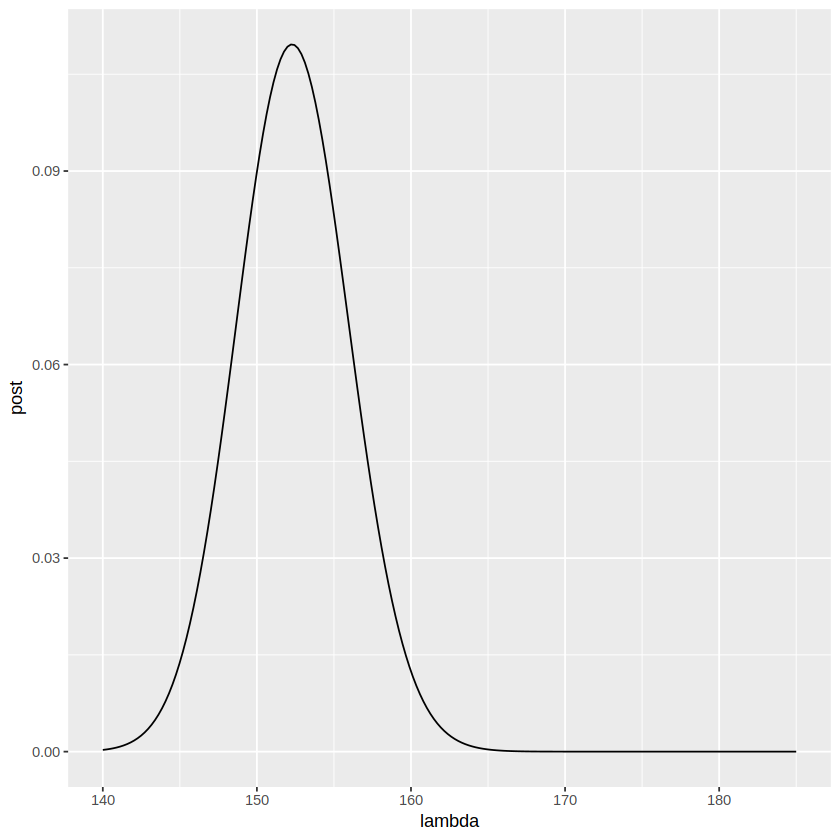

In [9]:
df = data.frame(lambda=l_grid, post=post)
p = ggplot(df, aes(lambda, post)) + geom_line()
p

# your code here
#.NotYetImplemented()

**1 (g) [3 points] Compute a $90\%$ credible interval and store it in a vector labeled, `cred_int`.**

In [45]:
cred_int = c(qgamma((1-0.9)/2, a + sum(fire), b + length(fire)), qgamma(1-(1-0.9)/2, a + sum(fire), b + length(fire)))
cred_int
# your code here
#.NotYetImplemented()

[1] 146.4327 158.4055

**1 (h) [2 points] [Multiple Choice] Do you have reason to believe that the rate of wildfires is different across these ten years when compared to past data?**    
Select the best response to this question and storing the number associated with the response in a variable labelled `choice`.    
1. No. The mean of the posterior is very close to $150$, and the credible interval covers $\lambda = 150$. Given this, we do not have reason to believe that the rate has changed.
2. No. When we look at the values in `fire` we see that they are, for the most part, very close to $150$. Given this, we do not have reason to believe that the rate has changed. 
3. Yes. The mean of the posterior is clearly above $150$ as observed in the plot in part 1 (f) and the shape of the posterior indicates we are very certain that the true mean is above $150$.

For example, if you believe the best response is #3, code: `choice=3` in the code block below.

In [13]:
choice = 1

# your code here
#.NotYetImplemented()

## Problem 2: Normal conjugate example

Suppose Company $A$ is considering using recycled cobalt in the smartphone batteries that it produces. Denote the true mean battery life (run time on a full charge) as $\mu$.  Company $A$ would like to know if there is evidence to strongly suggest that $\mu$ exceeds or falls short of $30$ hours ($30$ hours is the true mean battery life of the battery currently in use). Researchers' prior beliefs about $\mu$ can be represented by a normal distribution, centered at $\theta = 30$, with variance $\tau^2 = 4$. That is: $\mu \sim N(30, 4)$.

Suppose the researchers at company $A$ test $n = 5$ randomly selected phones with the recycled cobalt. Denote the battery life of phones in a possible sample as $X_1,...,X_n$. Assume that the standard deviation of battery life times is $\sigma = 1$) For this particular sample, the data $x_1,...,x_n$ were measured as:

In [47]:
x = c(28.3, 28.1, 29.1, 30, 30.1)

**2 (a) [5 points] Compute the posterior distribution mean and variance of $\mu \, | \, \mathbf{x}$ and store them in variables labeled `bat_mean` and `bat_var`, respectively.**

In [48]:
n = length(x)
sigma2 = 1
xbar = mean(x)
bat_mean = (n*xbar/sigma2 + 30/4) / (n/sigma2 + 1/4)
bat_var = 1 / (n/sigma2 + 1/4)

#mean(x)
#var(x)
bat_mean
bat_var

# your code here
#.NotYetImplemented()

[1] 29.1619

[1] 0.1904762

**2 (b) [2 points] [Multiple Choice] What would be a reasonable point estimate for $\mu$ given the data?**   
Select the best response to this question and storing the number associated with the response in a variable labelled `choice`.    
1. $\widehat\mu \approx 0.19$ 
2. $\widehat\mu \approx 29.2$ 
3. $\widehat\mu \approx 14.6$ 

For example, if you believe the best response is #3, code: `choice=3` in the code block below.

In [49]:
choice = 2

# your code here
#.NotYetImplemented()

**2 (c) [2 points] Calculate the prior distribution for a grid 300 evenly spaced values of $\mu$ between 20 and 40 (i.e., use `seq(20,40,length.out=300)`. Store the prior distribution in a vector labeled, `bat_prior`.**    

In [50]:
bat_grid = seq(20, 40, length.out=300)
bat_prior = dnorm(bat_grid, 30, 2)

# your code here
#.NotYetImplemented()

**2 (d) [3 points] Calculate the posterior distribution for the same grid of evenly spaced values of $\mu$ between 20 and 40. Store the posterior distribution in a vector labeled, `bat_post`. Using ggplot, plot the prior distribution and posterior distribution (on the same plot). Store the plot in a variable labeled, `bat_p`.**

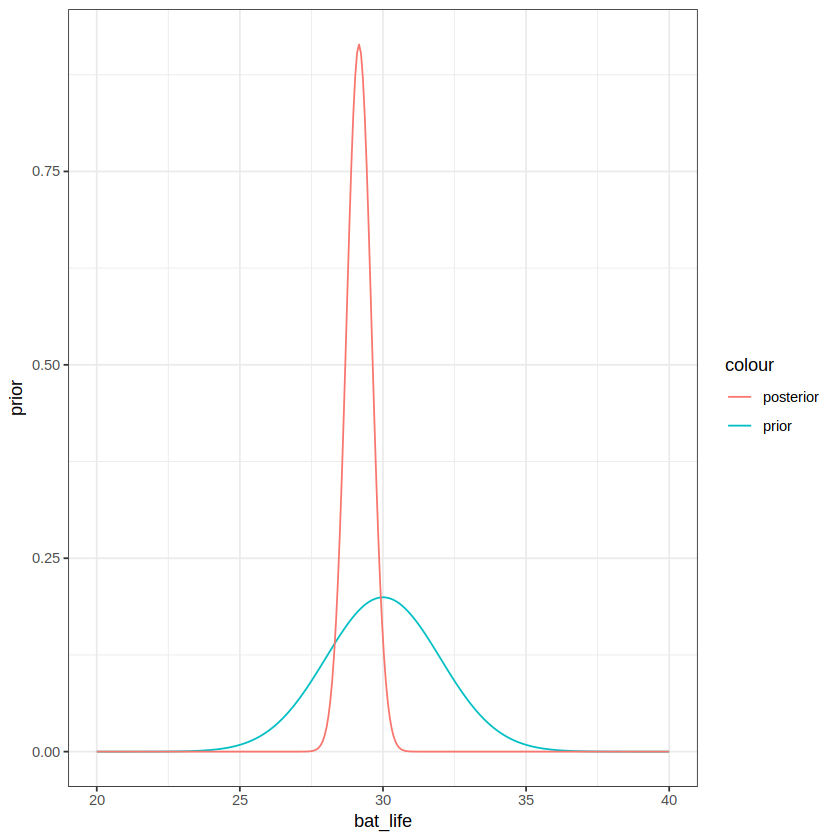

In [51]:
bat_post = dnorm(bat_grid, bat_mean, sqrt(bat_var))
df = data.frame(bat_life=bat_grid, prior=bat_prior, posterior=bat_post)
bat_p = ggplot(df) + geom_line(aes(bat_life, prior, col='prior')) + 
                     geom_line(aes(bat_life, posterior, col='posterior')) +
                     theme_bw()
bat_p

# your code here
#.NotYetImplemented()

**2 (e) [3 points] [Multiple Choice] What do you notice about the preceding plot?**
 
Select the best response to this question and storing the number associated with the response in a variable labelled `choice`.    
1. The prior reflects a high degree of uncertainty in the value of $\mu$. The posterior reflects less uncertainty. 
2. The posterior reflects a high degree of uncertainty in the value of $\mu$. The prior reflects less uncertainty.  
3. The posterior mean is shifted above the prior because the data suggest the true mean is greater than the researchers' hypothesis that $\mu$ is centered at 30.

For example, if you believe the best response is #3, code: `choice=3` in the code block below.

In [19]:
choice = 1

# your code here
#.NotYetImplemented()

**2 (f) [2 points] Compute a $95\%$ credible interval for $\mu$ given the data and store it in a vector labelled, `bat_cred`.**

In [52]:
bat_cred = c(qnorm((1-0.95)/2, bat_mean, sqrt(bat_var)), qnorm(1-(1-0.95)/2, bat_mean, sqrt(bat_var)))
bat_cred

# your code here
#.NotYetImplemented()

[1] 28.30651 30.01730

**2 (g) [2 points] [True or False] We have evidence to suggest that $\mu = 30$.**

1. TRUE. Given the data, and the prior, the probability that $\mu$ falls within $\approx (28.31, 30.02)$ is $0.95$, so we have evidence that $\mu = 30$.
2. FALSE. Given that the upper end of the confidence interval is almost 30, we can't say we have evidence to suggest $\mu = 30$.

If you believe this statement is true, code `response=TRUE` into the code block below.  If you believe this statement to be false, code `response=FALSE` in the code block below.  Be sure to use all CAPS after the = sign.

In [53]:
response = TRUE

# your code here
#.NotYetImplemented()

**2 (h) [5 points] Now, suppose instead that prior to the experiment, researchers believed that $\mu = 45$ was the center of the prior distribution, with $\tau^2 = 1$. Compute the posterior distribution for this prior (for the same data as above) for a grid 300 evenly spaced values of $\mu$ between 20 and 50 (i.e., use `seq(20,50,length.out=300)`. Store the posterior distribution in a vector labelled, `bat_post2` and using ggplot reproduce the plot from above and store in as variable `bat_p2`**

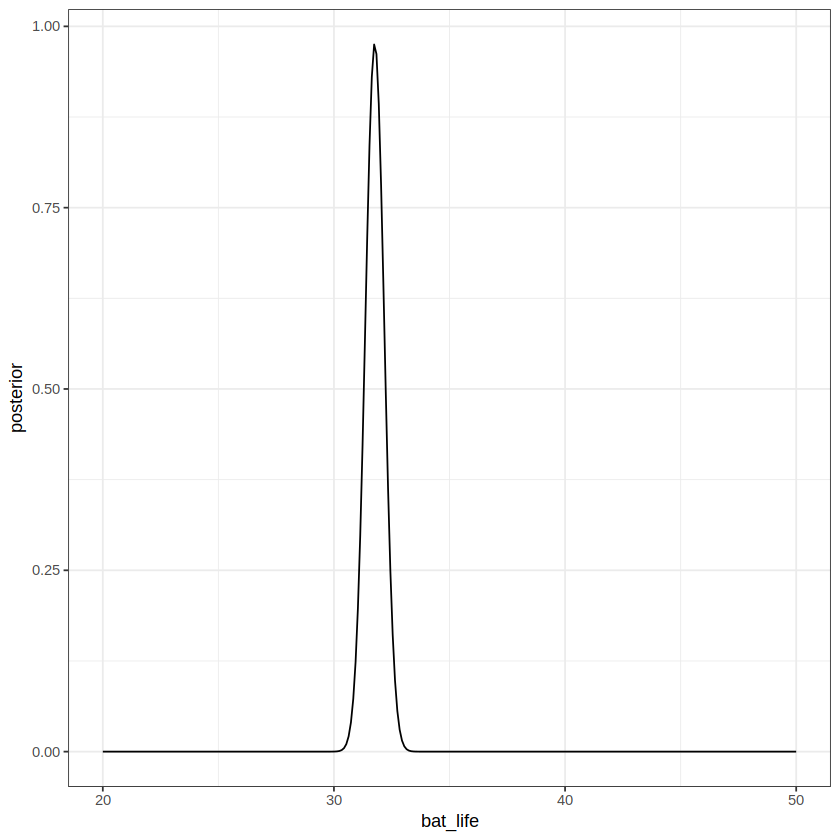

In [57]:
n = length(x)
sigma2 = 1
xbar = mean(x)
bat_grid = seq(20, 50, length.out=300)
bat_mean2 = (n*xbar/sigma2 + 45/1) / (n/sigma2 + 1/1)
bat_var2 = 1 / (n/sigma2 + 1/1)

bat_prior2 = dnorm(bat_grid, 45, 1)
bat_post2 = dnorm(bat_grid, bat_mean2, sqrt(bat_var2))
#df = data.frame(bat_life=bat_grid, prior=bat_prior2, posterior=bat_post2)
df = data.frame(bat_life=bat_grid, posterior=bat_post2)
bat_p2 = ggplot(df) + 
            #geom_line(aes(bat_life, prior, col='prior')) + 
            #geom_line(aes(bat_life, posterior, col='posterior')) +
            geom_line(aes(bat_life, posterior)) +
            theme_bw()
bat_p2
# your code here
#.NotYetImplemented()

**2 (i) [2 points] [Multiple Choice] Which response below best describe the difference between the posterior you just calculated and plotted and the one from previous parts of this problem?**
 
Select the best response to this question and storing the number associated with the response in a variable labeled `choice`.    
1. The new likelihood function has caused the center of the posterior to shift upward. 
2. The posterior has caused the center of the prior to shift upward.  
3. The prior has caused the center of the posterior to shift upward.

For example, if you believe the best response is #3, code: `choice=3` in the code block below.

In [73]:
choice = 3

# your code here
#.NotYetImplemented()

**2 (j) [2 points] Compute a credible interval for this new posterior distribution and store it in a vector labeled, `bat_cred2`.**

In [58]:
bat_cred2 = c(qnorm((1-0.95)/2, bat_mean2, sqrt(bat_var2)), qnorm(1-(1-0.95)/2, bat_mean2, sqrt(bat_var2)))
bat_cred2

# your code here
#.NotYetImplemented()

[1] 30.96651 32.56682

**2 (k) [2 points] [True or False] We have evidence to suggest that $\mu = 30$.**

1. TRUE. Given the data, and the prior, we see that $\mu = 30$ is nearly within the credible interval.  It's close enough to serve as evidence to suggest $\mu = 30$.
2. FALSE. Given the data, and the prior, the probability that $\mu$ falls within $\approx (31.00, 32.57)$ is $0.95$. $\mu = 30$ is outside of this interval.

If you believe this statement is true, code `response=TRUE` into the code block below.  If you believe this statement to be false, code `response=FALSE` in the code block below.  Be sure to use all CAPS after the = sign.

In [ ]:
response = FALSE

# your code here
#.NotYetImplemented()

## Problem 3: The negative binomial revisited

Let $X$ represent the number of failures observed before $r$ successes are observed in a set of independent Bernoulli trials. That is, let $X$ be negative binomial$(r, p)$ with $r$ known and $p$ unknown with the usual distribution used for probabilities. Set $r = 3$, $X = 10$, and $\alpha = 3$ and $\beta = 1$.

**3 (a) [3 points] Calculate the prior distribution using a grid of 200 evenly spaced values of $p$ from 0.001 to 0.999 and store it in a vector labeled `prior`. Store your grid in a vector labeled, `p_grid`. Calculate the likelihood function for the same grid of $p$ values and store it in a vector labeled, `l`.**

In [2]:
p_grid = seq(0.001, 0.999, length.out=200)
prior = dbeta(p_grid, 3, 1)
l = dnbinom(10, size=3, prob=p_grid)
#l
# your code here
#.NotYetImplemented()

**3 (b) [3 points] Calculate posterior distribution for the same grid of $p$ values calculated in 3 (a) and store it in a vector labeled, `post_nb`.**

In [18]:
#post_nb = prior*l
#post_nb = post_nb / sum(post_nb)
post_nb = dbeta(p_grid, 6, 11) # (3+3, 1+10)
#sum(post_nb)
# your code here
#.NotYetImplemented()

**3 (c) [2 points] Using ggplot, plot the prior, likelihood function and posterior distribution of $p$ given the data.  Store the plot in a variable labeled `pp`.  When plotting the likelihood multiply it by a factor of 40 or so to ensure it is visible on the plot.**

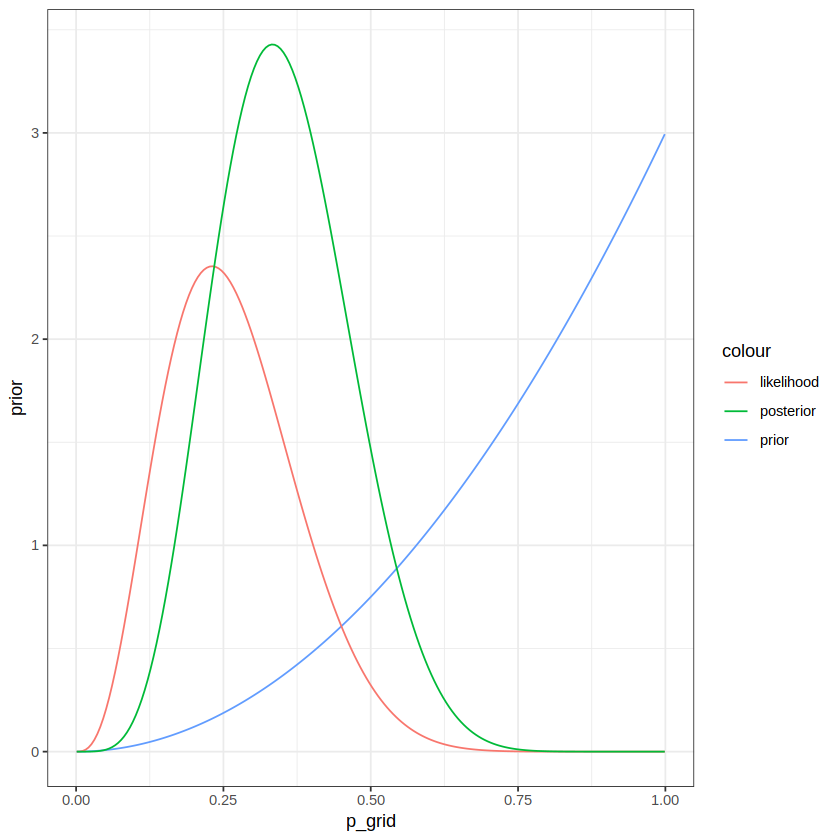

In [19]:
df = data.frame(p=p_grid, prior=prior, likelihood=l*40, posterior=post_nb)
pp = ggplot(df) + 
            geom_line(aes(p_grid, prior, col='prior')) + 
            geom_line(aes(p_grid, likelihood, col='likelihood')) + 
            geom_line(aes(p_grid, posterior, col='posterior')) +
            theme_bw()
pp

# your code here
#.NotYetImplemented()

 **3 (d) [2 points] Give a $95\%$ credible interval based on the posterior in the previous part. Store the credible interval in a vector labeled `cred_int2`.**

In [20]:
#cred_int2 = NA
#length(post_nb)
#sum(post_nb)
#post_nb <- post_nb / sum(post_nb)
#cum_post <- cumsum(post_nb)

#cred_int2 <- c(
#  p_grid[which(cum_post >= 0.025)[1]],
#  p_grid[which(cum_post >= 0.975)[1]]
#)
#cred_int2

cred_int2 = c(qbeta((1-0.95)/2, 6, 11), qbeta(1-(1-0.95)/2, 6, 11))
cred_int2

# your code here
#.NotYetImplemented()

[1] 0.1519837 0.5866206

**3 (e) [8 points] Suppose we'd like to make a prediction about the number of failures, $X^*$, that we are likely to observe before the *next* $r = 3$ trials. Estimate the posterior predictive distribution using Monte Carlo simulations. Draw from the posterior predictive distribution $m=5000$ times. Store the values drawn from the posterior predictive distribution in a vector labeled, `pred_sim`.**

[1] 6.6368

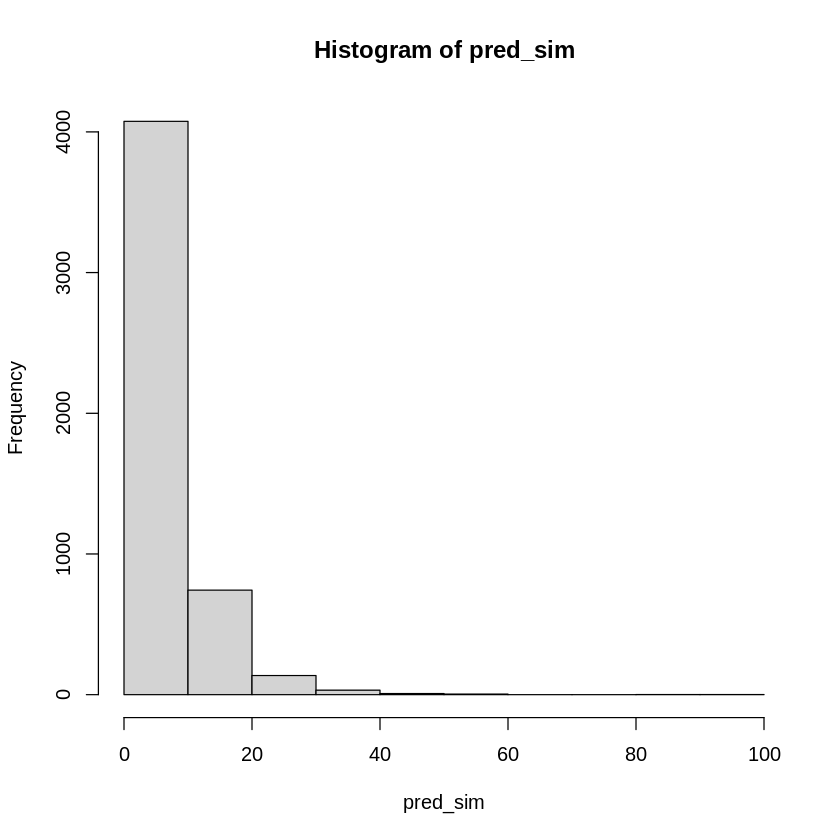

In [7]:
set.seed(99) 
m = 5000  # number of draws from the posterior predictive distribution
pred_sim <- matrix(NA, nrow=m)
r_star <- 3
for (i in 1:m) {
    p_star <- rbeta(1, 3+3, 1+10)
    pred_sim[i] <- rnbinom(1, size=r_star, prob=p_star)
}
mean(pred_sim)
hist(pred_sim)
# your code here
#.NotYetImplemented()

**3 (f) [8 points] Now, using the values stored in `pred_sim`, calculate the relative frequencies for  $X^* = 1, 2, ...$ and store the relative frequencies for these values in a vector labeled `freq` (e.g. `freq`[1] should be the relative frequency that there are no failures before the *next* $r = 3$ trials. `freq`[2] should be the relative frequency that there is 1 failure before the *next* $r = 3$ trials, ...).**

In [25]:
#set.seed(99)
#freq = table(pred_sim) #as.numeric() #/ length(pred_sim))
#freq
freq = tabulate(as.factor(pred_sim))/m
freq
#sum(freq)
# your code here
#.NotYetImplemented()

[1] 0.0518 0.0892 0.1072 0.1070 0.1042 0.0924 0.0764 0.0578 0.0504 0.0420
[11] 0.0366 0.0316 0.0218 0.0196 0.0158 0.0140 0.0166 0.0096 0.0086 0.0070
[21] 0.0040 0.0036 0.0050 0.0044 0.0028 0.0030 0.0024 0.0022 0.0014 0.0014
[31] 0.0010 0.0008 0.0006 0.0012 0.0008 0.0008 0.0006 0.0008 0.0004 0.0004
[41] 0.0004 0.0002 0.0004 0.0004 0.0002 0.0004 0.0002 0.0002 0.0002 0.0002

**3 (g) [5 points] Using ggplot, plot a histogram of the frequencies and store in a variable `MC_p`.**

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


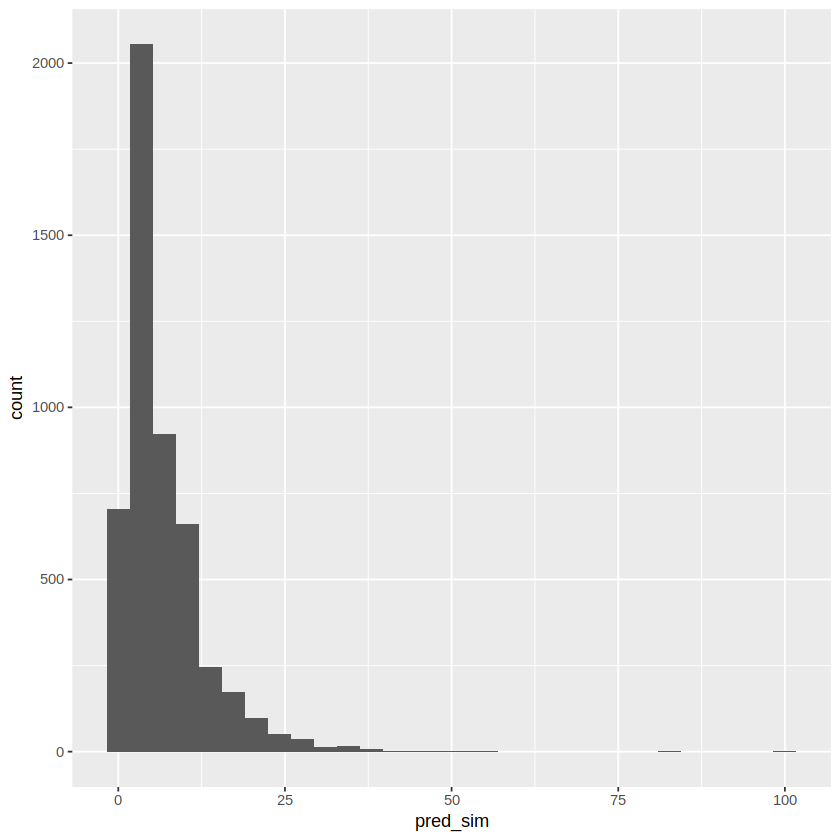

In [10]:
MC_p = ggplot(data.frame(pred_sim)) + geom_histogram(aes(pred_sim))
MC_p
# your code here
#.NotYetImplemented()

**3 (h) [6 points] Let $X^*$ be the number of failures observed before $r = 3$ successes on a future set of Bernoulli trials.  Using the frequencies stored in `freq` estimate $P(0 \le X^* \le 10)$ and store it in a variable labeled `prob`.**

In [82]:
prob = sum(freq[1:11]) / sum(freq)
prob

# your code here
#.NotYetImplemented()

[1] 0.815